# **3.7.2 Cost versus Time Trade-Offs**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1wgB1AT5dwmi9sJ2iX8OVZBIn8wt_OHS_?usp=sharing)

The methods presented thus far have dealt solely with scheduling activities in order to achieve a minimum project duration, and no consideration has been given to the cost of the project. In addition to *direct costs* associated with each individual activity, there are typically *indirect costs* that may be viewed as overhead costs and that are proportional to the duration of the entire project. These costs may include such expenses as administrative or supervisory costs, equipment and facilities rental, and interest on capital. A financially realistic project manager may be willing to add resources, involving some direct expense, to certain activities in order to reduce the duration of those activities, and thereby to reduce the project duration and the attendant indirect costs. CPM provides a mechanism for minimizing the *total* direct plus indirect costs of a project.

&nbsp;&nbsp;&nbsp;&nbsp;Suppose that for every activity, we know the normal duration and the budgeted cost associated with completing the activity under normal circumstances. Suppose also that, through additional expenditures, the duration of each activity can be reduced. This is known as **crashing**. For each activity then, we know the **crash completion time** and the


<div align="center">

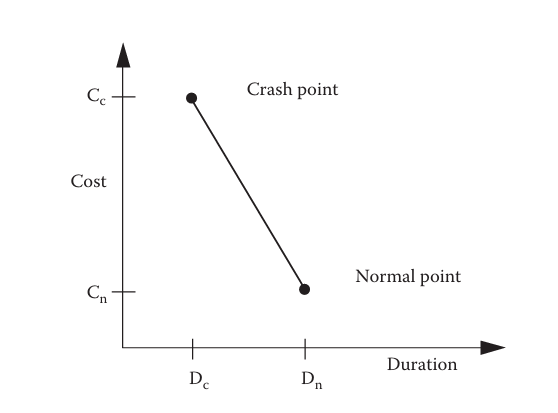

</div>

**FIGURE 3.22** <br>
Cost versus time trade-off.

<br>

**crash cost**. By crashing critical jobs, total project length can be reduced. If the cost of crashing is less than the indirect costs that can be saved, then we not only reduce total costs but we can also enjoy various subjective benefits associated with completing a project ahead of schedule.

&nbsp;&nbsp;&nbsp;&nbsp;**Figure 3.22** shows a straight-line relationship that is typically assumed, describing crash costs and durations and normal costs and durations. Each activity has its own cost vs. time trade-off, represented by the *slope* of the straight line, and its own crash point, or **crash limit**, beyond which no amount of added resources can reduce the activity’s duration.

&nbsp;&nbsp;&nbsp;&nbsp;We take advantage of cost vs. time trade-offs in the following way. Using normal costs and durations for all activities, we first determine a critical path, as before. Then we consider reducing the duration of critical activities.

&nbsp;&nbsp;&nbsp;&nbsp;If we crash all the critical activities simultaneously, then almost certainly the network’s critical path will have changed, and we suddenly find that we are working on the wrong problem. Instead, we should choose *one* of the critical activities to crash; in particular, we should choose the one that will yield the greatest reduction in schedule length per unit of added costs. This choice is easily made by simply selecting the activity having the smallest cost vs. time slope.

&nbsp;&nbsp;&nbsp;&nbsp;Having now chosen which critical activity to crash, we must still proceed with caution. As the duration of a critical activity is reduced, the activity may cease to be critical, there is now a new critical path in the network. At this point, it is useless to further reduce this activity, and instead we should be investing in the reduction of some *currently* critical activity. It has been suggested that the least-slope critical activity be crashed by only one time unit, then a possibly new critical path found. This process is repeated until all critical activities are at their crash limits.

&nbsp;&nbsp;&nbsp;&nbsp;Another consideration in deciding how far to crash an activity is the reduction in indirect costs that can be achieved. Since the aim is presumably to minimize the *sum* of activity costs and indirect costs, every crash operation should be undertaken only if it can be justified with respect to total project costs.

&nbsp;&nbsp;&nbsp;&nbsp;As an example, consider again the project network of **Figure 3.21**. The normal and crash points for each activity are given in **Table 3.22**, where $D_n$ denotes the normal duration of the activity, $C_n$ denotes the normal cost, $D_c$ denotes the crash limit, and $C_c$ denotes the crash cost. The cost versus time slopes for each activity are computed as $(C_c - C_n)/(D_n - D_c)$, and are shown in the far right column.

<br>

<div align="center">

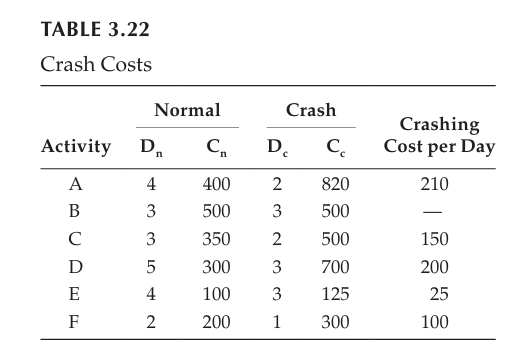

</div>

&nbsp;&nbsp;&nbsp;&nbsp;Suppose that indirect costs amount to ＄220/day; therefore, the total project cost under a normal schedule is $(400 + 500 + 350 + 300 + 100 + 200) + (＄220/\text{day} \cdot 11 \text{ days}) = 1850 + 2420 = ＄4270$. If all activities were at their crash point, then the project duration would be 7 days, and the total project cost would be $(820 + 500 + 500 + 700 + 125 + 300) + (＄220/\text{day} \cdot 7 \text{ days}) = 2945 + 1540 = ＄4485$. Clearly in this case, we are paying crash costs for activities that do not contribute to the reduction in project length. So, we would expect the optimal schedule to fall somewhere between these two extremes.

&nbsp;&nbsp;&nbsp;&nbsp;Beginning with the normal schedule, where the critical activities are A, D, and F, we find that we can crash activity F at a cost of only ＄100/day; and by crashing activity F to its limit, we can reduce total overhead by ＄220, for a net savings of ＄120. The total project cost would then be ＄4150, and the project duration is 10 days.

&nbsp;&nbsp;&nbsp;&nbsp;The critical path has not changed, so we now consider critical activities A and D. The daily reduction at the least cost is obtained by crashing activity D. Crashing D by one day costs ＄200, but saves ＄220; therefore, the total cost is now ＄4130, and project duration is nine days. Since the critical path still includes activity D, we can crash it by one additional day, to obtain an eight-day project at a total cost of ＄4110.

&nbsp;&nbsp;&nbsp;&nbsp;Activity A is now the only critical activity that is not at its crash limit, and we can save ＄220 − ＄210 = ＄10 by crashing A to three days for a total project cost of ＄4100. At this point activities A and B are on parallel critical paths; therefore, any crashing must be applied simultaneously to both projects. In our case, project B cannot be crashed, and therefore the project duration cannot be reduced to less than seven days. Notice that if project B could have been reduced but if the combined cost of crashing activities A and B exceeded ＄220, then crashing them would not have been economical.

&nbsp;&nbsp;&nbsp;&nbsp;Since critical activities A, B, D, and F are all crashed as far as possible to reduce the project duration, the current schedule is optimal. The durations of activities A, B, C, D, E, and F, respectively, are 3, 3, 3, 3, 4, and 1. The project cost is $(610 + 500 + 350 + 700 + 100 + 300) + 7(220) = 2560 + 1540 = ＄4100$.

**Code Implementation**

In [ ]:
# ========================================
# 3.7.2 Cost versus Time Trade-Offs
# Crash Cost Calculations
# ========================================

import pandas as pd

# Activity crash data from Table 3.22
data = {
    "Activity": ["A", "B", "C", "D", "E", "F"],
    "Normal Duration": [4, 3, 3, 5, 4, 2],
    "Normal Cost": [400, 500, 350, 300, 100, 200],
    "Crash Duration": [2, 3, 2, 3, 3, 1],
    "Crash Cost": [820, 500, 500, 700, 125, 300]
}

df = pd.DataFrame(data)

# Calculate crashing cost per day
def crash_slope(row):
    time_saved = row["Normal Duration"] - row["Crash Duration"]
    cost_added = row["Crash Cost"] - row["Normal Cost"]

    if time_saved == 0:
        return None
    return cost_added / time_saved

df["Crashing Cost per Day"] = df.apply(crash_slope, axis=1)

print("Crash Cost Table:")
display(df)

# Indirect cost per day
indirect_cost_per_day = 220

# Normal project cost
normal_direct_cost = df["Normal Cost"].sum()
normal_duration = 11
normal_total_cost = normal_direct_cost + indirect_cost_per_day * normal_duration

print("Normal Schedule:")
print("Direct Cost:", normal_direct_cost)
print("Project Duration:", normal_duration)
print("Total Cost:", normal_total_cost)

# All-crash project cost
crash_direct_cost = df["Crash Cost"].sum()
crash_duration = 7
crash_total_cost = crash_direct_cost + indirect_cost_per_day * crash_duration

print("\nAll-Crash Schedule:")
print("Direct Cost:", crash_direct_cost)
print("Project Duration:", crash_duration)
print("Total Cost:", crash_total_cost)

# Textbook crashing sequence
steps = [
    {
        "Step": "Normal schedule",
        "Durations A,B,C,D,E,F": "4, 3, 3, 5, 4, 2",
        "Project Duration": 11,
        "Direct Cost": 1850,
        "Indirect Cost": 220 * 11,
        "Total Cost": 4270
    },
    {
        "Step": "Crash F by 1 day",
        "Durations A,B,C,D,E,F": "4, 3, 3, 5, 4, 1",
        "Project Duration": 10,
        "Direct Cost": 1950,
        "Indirect Cost": 220 * 10,
        "Total Cost": 4150
    },
    {
        "Step": "Crash D by 1 day",
        "Durations A,B,C,D,E,F": "4, 3, 3, 4, 4, 1",
        "Project Duration": 9,
        "Direct Cost": 2150,
        "Indirect Cost": 220 * 9,
        "Total Cost": 4130
    },
    {
        "Step": "Crash D by 1 more day",
        "Durations A,B,C,D,E,F": "4, 3, 3, 3, 4, 1",
        "Project Duration": 8,
        "Direct Cost": 2350,
        "Indirect Cost": 220 * 8,
        "Total Cost": 4110
    },
    {
        "Step": "Crash A by 1 day",
        "Durations A,B,C,D,E,F": "3, 3, 3, 3, 4, 1",
        "Project Duration": 7,
        "Direct Cost": 2560,
        "Indirect Cost": 220 * 7,
        "Total Cost": 4100
    }
]

steps_df = pd.DataFrame(steps)

print("\nCrashing Sequence:")
display(steps_df)

best_step = steps_df.loc[steps_df["Total Cost"].idxmin()]

print("Optimal Schedule:")
print(best_step["Step"])
print("Durations A,B,C,D,E,F:", best_step["Durations A,B,C,D,E,F"])
print("Project Duration:", best_step["Project Duration"])
print("Minimum Total Cost:", best_step["Total Cost"])

Crash Cost Table:


,Activity,Normal Duration,Normal Cost,Crash Duration,Crash Cost,Crashing Cost per Day
0,A,4,400,2,820,210.0
1,B,3,500,3,500,NaN
2,C,3,350,2,500,150.0
3,D,5,300,3,700,200.0
4,E,4,100,3,125,25.0
5,F,2,200,1,300,100.0


Normal Schedule:
Direct Cost: 1850
Project Duration: 11
Total Cost: 4270

All-Crash Schedule:
Direct Cost: 2945
Project Duration: 7
Total Cost: 4485

Crashing Sequence:


,Step,"Durations A,B,C,D,E,F",Project Duration,Direct Cost,Indirect Cost,Total Cost
0,Normal schedule,"4, 3, 3, 5, 4, 2",11,1850,2420,4270
1,Crash F by 1 day,"4, 3, 3, 5, 4, 1",10,1950,2200,4150
2,Crash D by 1 day,"4, 3, 3, 4, 4, 1",9,2150,1980,4130
3,Crash D by 1 more day,"4, 3, 3, 3, 4, 1",8,2350,1760,4110
4,Crash A by 1 day,"3, 3, 3, 3, 4, 1",7,2560,1540,4100


Optimal Schedule:
Crash A by 1 day
Durations A,B,C,D,E,F: 3, 3, 3, 3, 4, 1
Project Duration: 7
Minimum Total Cost: 4100
